# Performance analysis of the bots

Performance analysis of the different bots in `The Number Game`.

`This is still a work in progress. Please excuss my sloppy notes`

## Table of Content

- [Performance analysis of the bots](#performance-analysis-of-the-bots)
  - [Introduction](#introduction)  <!-- NOT OKAY Yet -->
  - [Linear search bot](#linear-search-bot)
  - [RandoBot](#randobot)  <!-- NOT OKAY Yet -->
  - [RandoBot with memory](#randobot-with-memory)  <!-- NOT OKAY Yet -->
  - [Binary search bot](#binary-search-bot)  <!-- NOT OKAY Yet -->
  - [Conclusion](#conclusion)  <!-- NOT OKAY Yet -->

## Introduction

In the number game we start by picking a random interger on the closed interval $[1, N]$ where `N` is a large positive integer. This is called then `target number` and is denoted with a `t`. This number is picked uniformly, so the probability of have target number $t \in [1, N]$ is
$$
    P(t) = \frac{1}{N}.
$$

## Linear search bot

LinearSearchbot simply starts by guessing 1, then 2, then 3, and so on. It is probably the simplest way to guarantee that you eventually guess the correct number, but it is very slow. For a given target value `t`, it would take `LinearSearchBot` exactly `t` guesses to find the correct value. The probability for `LinearSearchBot` to win the game in a given number of moves 
$$
    P(n|\text{LinearSearchBot \& target} \in [1, N]) = P(\text{target} = n | \text{target} \in [1, N]) = \frac{1}{N}
$$ 
is therefore uniform over the interval $[1, N]$. This can be demonstrated by running 50,000 games with a maximum target value of 1,000.


In [ ]:
"""Running experiment with linear search bot"""
import matplotlib.pyplot as plt

from numbergame.game import Game
from numbergame.bots import LinearSearchBot
from numbergame.statistics import run_experiment


N_MAX = 1_000
N_RUNS = 50_000

statistics_single_run = run_experiment(LinearSearchBot, N_MAX, N_RUNS)
statistics_single_run

NameError: name 'Game' is not defined

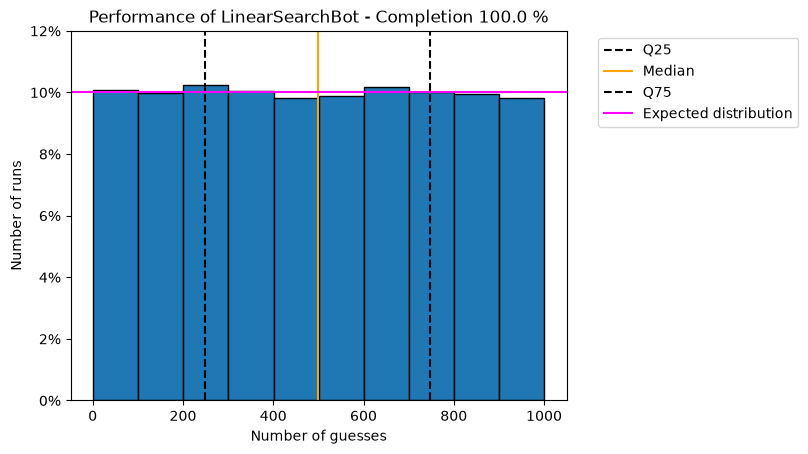

In [ ]:
BINS = 10

fig, ax, _ = statistics_single_run.plot(bins=BINS, edgecolor='black')
ax.axhline(N_RUNS / BINS, linestyle='-', color='magenta', label='Expected distribution')
ax.set_xlabel('Number of guesses')
ax.set_ylabel('Number of runs')
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f"{100 * x / N_RUNS:.0f}%"  for x in ax.get_yticks()])
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

As you clearly can see, the percentage of runs is homogeneous distributed amoungs with number of guesses. Here Q25 and Q75 are the 25 % and 75 % quarentiles. Here 25 % of all runs had a number of guesses below the Q25 line. Likewise, 25 % of all runs had a number of guesses above the Q75 line. The median divides dataset in half and lied exactly between the Q25 and Q75 line.

### Expected average performance

As we expected, the probability of needing `n` guesses is homogeneous. It is therefore very trivial to calculate the averate performance this strategy.
$$
    \left\langle n \right\rangle = \sum_{n = 1}^N n P(n) = \frac{N + 1}{2}.
$$
guesses to win given `N` is the maximum guess value. Note that for even values if `N`, the average is a non-integer value, which is okay, since we are working with averages. 

This results yields a linear relationship between the maximum target value `N` and the average performance of `LinearSearchBot`, also written as $\left\langle n \right\rangle = \mathcal{O}(N)$. This can also be shown by running the same experiment as above for different values of `N`, measure their average performance and plotting the results against each other. 

In [7]:
"""Running 10_000 simulations for each size in [100, 200, 300, ..., 1_000]"""
import time
import numpy as np

N_RUNS = 10_000
bot = LinearSearchBot()

sizes = [int(x) for x in np.arange(100, 1_001, step=100, dtype=int)]

dataset_linear_search_bot = {}
for n_max in sizes:
    print(f"Measure data for {n_max=} in: ", end="")
    game = Game(bot, max_target=n_max, max_questions=50_000)
    t_start = time.perf_counter()
    dataset_linear_search_bot[n_max] = run_experiment(game, N_RUNS, verbose=False)
    t_end = time.perf_counter()
    print(f"{t_end - t_start:0.1f} seconds")
dataset_linear_search_bot

Measure data for n_max=100 in: Running batch 1/10 with batchsize 1000: Finished in 0.04 seconds
Running batch 2/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 3/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 4/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 5/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 6/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 7/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 8/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 9/10 with batchsize 1000: Finished in 0.02 seconds
Running batch 10/10 with batchsize 1000: Finished in 0.02 seconds
0.2 seconds
Measure data for n_max=200 in: Running batch 1/10 with batchsize 1000: Finished in 0.04 seconds
Running batch 2/10 with batchsize 1000: Finished in 0.04 seconds
Running batch 3/10 with batchsize 1000: Finished in 0.04 seconds
Running batch 4/10 with batchsize 1000: Finished in 0.04 seconds
Running batch 5

{100: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=50.69, std=28.84, quarentiles=QuartilesInfo(min=1, q25=26, median=51, q75=76, max=100), completion_percentage=100.0),
 200: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=99.81, std=57.48, quarentiles=QuartilesInfo(min=1, q25=50, median=99, q75=150, max=200), completion_percentage=100.0),
 300: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=150.56, std=86.56, quarentiles=QuartilesInfo(min=1, q25=75, median=151, q75=225, max=300), completion_percentage=100.0),
 400: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=200.53, std=115.18, quarentiles=QuartilesInfo(min=1, q25=101, median=200, q75=300, max=400), completion_percentage=100.0),
 500: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=252.92, std=144.12, quarentiles=QuartilesInfo(min=1, q25=130, median=253, q75=377, max=500), completion_

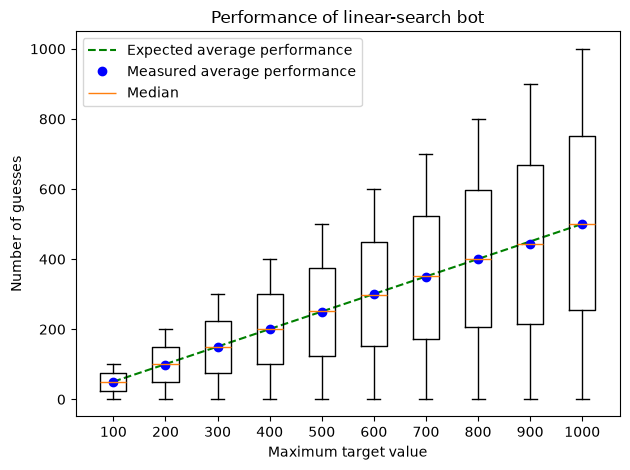

In [4]:
import numpy as np

size_array = np.array(list(dataset_linear_search_bot), dtype=int)
data_array = np.array([data.quarentiles for data in dataset_linear_search_bot.values()]).T


fig, ax = plt.subplots()
ax.plot(size_array, 0.5 * (size_array + 1), '--', color='green', label='Expected average performance')
ax.plot(size_array, [data.mean for data in dataset_linear_search_bot.values()], 'ob', label='Measured average performance')
ax.boxplot(data_array,
           positions=list(dataset_linear_search_bot), 
           widths=(sizes[1] - sizes[0]) // 2,
           label='Median')

ax.set_xlabel('Maximum target value')
ax.set_ylabel('Number of guesses')
ax.set_title('Performance of linear-search bot')
ax.legend()
fig.tight_layout()

As expected, the average performance, represented by the <span style="color:blue;">blue dots</span> scale linear with the maximum target value. The boxes again show the median number of guesses (<span style="color:orange;">orange line</span>) the Q25 and Q75 lines (edge of boxes). The minimum and maximum values are here 1 and the maximum target values. This is no supprise since LinearSearchBot will guess 1 in a single guess and the maximum target value using the maximum number of guesses.

### Sub-conclusion

Althou the LinearSearchBot in guarenteed to guess the target value, its performance is not particularly impressive. Its results spans uniformly from using only a single guess to using the maximal number of guesses.

## RandoBot

RandoBot is not the brightest kid in class. Its guesses are completly random within the bounds of the question: $[1, N]$ and does not remember anything. The probabilit yof guessing an integer in the integerval $[1, N]$ is therefore 
$$
    p := P(n = \text{target} | \text{target} \in [1, N]) = \frac{1}{N}.
$$

Given a run of `L` guesses, `RandoBot` must have guessed the first `L - 1` guesses wrong, with a probability of `(1 - p)`, and the last guess correct with a probability of `p`. Therefore, the probability of having a run length of `L` must be
$$
    P(L | \text{target} \in [1, N]) = (1 - p)^{L - 1} p
$$

Again this can be shown by running 50,000 runs with a maximum target value of 1000 and plot the results in a histogram.

In [8]:
"""Running experiment with RandoBot"""
import matplotlib.pyplot as plt

from numbergame.game import Game
from numbergame.bots import RandoBot
from numbergame.statistics import RunStatistics


N_MAX = 1_000
N_RUNS = 50_000
MAX_QUESTIONS = 5_000

bot = RandoBot()
game = Game(bot, max_target=N_MAX, max_questions=MAX_QUESTIONS)

statistics_single_run = RunStatistics(RandoBot, [game.run() for _ in range(N_RUNS)])
statistics_single_run

RunStatistics(bottype='RandoBot', n_total=50000, n_sucess=49679, mean=967.83, std=909.76, quarentiles=QuartilesInfo(min=1, q25=287, median=688, q75=1373, max=4997), completion_percentage=99.36)

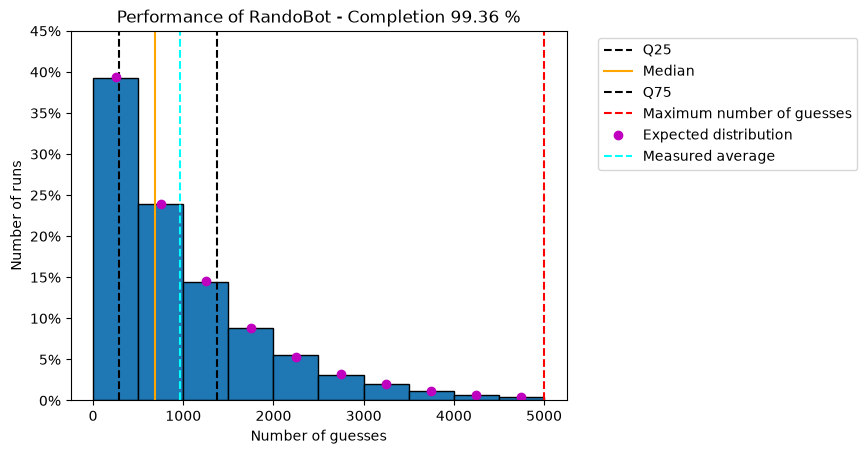

In [36]:
BINS = 10

p = 1 / N_MAX

fig, ax, (count, bins) = statistics_single_run.plot(bins=BINS, edgecolor='black')

bin_center = 0.5 * (bins[1:] + bins[:-1])
expected_count = N_RUNS * ((1 - p)**(bins[:-1] - 1) - (1 - p)**bins[1:])

ax.axvline(MAX_QUESTIONS, linestyle='--', color='red', label='Maximum number of guesses')
ax.plot(bin_center, expected_count, 'om', label='Expected distribution')
ax.axvline(statistics_single_run.mean, linestyle='--', color='cyan', label='Measured average')

ax.set_xlabel('Number of guesses')
ax.set_ylabel('Number of runs')
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f"{100 * x / N_RUNS:.0f}%"  for x in ax.get_yticks()])
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

### Average performance of RandoBot

$$
    \left\langle n \right\rangle 
        = \sum_{i = 1}^\infty i\ P(\text{score} = i)
        = \sum_{i = 1}^\infty i (1 - f)^{i - 1} f
        % = f \frac{d}{dx} \sum_{i=0}^\infty x^i \Big|_{x = 1 - f}
        % = f \frac{d}{dx} \frac{1}{1 - x} \Big|_{x = 1 - f}
        % = \frac{f}{(1 - x)^2}\Big|_{x = 1 - f}
        = f^{-1} 
        = N_\text{max}
$$

In [37]:
"""
Running 10_000 simulations for each size in [100, 200, 300, ..., 1_000]
"""
import time
import numpy as np

N_RUNS = 10_000
bot = RandoBot()

sizes = [int(x) for x in np.arange(100, 1_000, step=100, dtype=int)]

dataset_randobot = {}
for n_max in sizes:
    print(f"Measure data for {n_max=} in: ", end="")
    game = Game(bot, max_target=n_max, max_questions=50_000)
    t_start = time.perf_counter()
    dataset_randobot[n_max] = RunStatistics(RandoBot, [game.run() for _ in range(N_RUNS)])
    t_end = time.perf_counter()
    print(f"{t_end - t_start:0.1f} seconds")
dataset_randobot

Measure data for n_max=100 in: 0.6 seconds
Measure data for n_max=200 in: 1.0 seconds
Measure data for n_max=300 in: 1.7 seconds
Measure data for n_max=400 in: 2.2 seconds
Measure data for n_max=500 in: 

KeyboardInterrupt: 

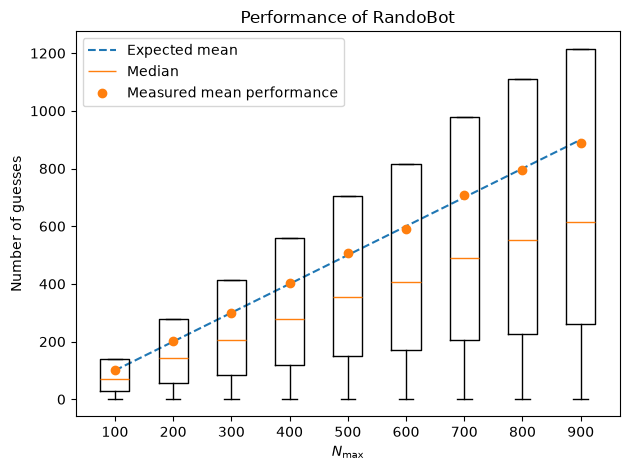

In [ ]:
import numpy as np

size_array = np.array(list(dataset_randobot), dtype=int)
data_array = np.array([data.quarentiles for data in dataset_randobot.values()]).T

fig, ax = plt.subplots()
ax.plot(size_array, size_array, '--', label='Expected mean')
ax.boxplot(data_array,
           positions=list(dataset_randobot),
           widths=(sizes[1] - sizes[0]) // 2,
           showfliers=False,
           label='Median')
ax.plot(size_array, [data.mean for data in dataset_randobot.values()], 'o', label='Measured mean performance')

ax.set_xlabel('$N_\\text{max}$')
ax.set_ylabel('Number of guesses')
ax.set_title('Performance of RandoBot')
ax.legend()
fig.tight_layout()

### Average spread of RandoBot
 

$$
    \left\langle n^2 \right\rangle 
        = \sum_{i = 1}^\infty i^2\ P(\text{score} = i)
        = \sum_{i = 1}^\infty i^2 (1 - f)^{i - 1} f
        = f \sum_{i = 1}^\infty [(i+1)\ i\ x^{i - 1} f - i\ x^{i - 1}] \Big|_{x = 1 - f}
        = 2N_\text{max}^2 - N_\text{max}
$$

$$
    \sigma^2 =  N_\text{max}\left(N_\text{max} - 1\right)
$$

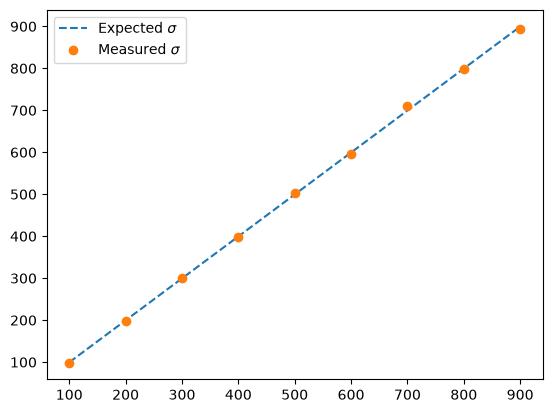

In [ ]:
fig, ax = plt.subplots()
ax.plot(size_array, np.sqrt(size_array*(size_array - 1)), '--', label=r'Expected $\sigma$')
ax.plot(size_array, [data.std for data in dataset_randobot.values()], 'o', label=r'Measured $\sigma$')
ax.legend()

## RandoBot with memory

## Binary search bot

The binary search bot is a clever one. It uses what is known as a [binary search](https://en.wikipedia.org/wiki/Binary_search) to guess the correct number. The idea is to consider consider all intergers in the interval $[1, N]$. If the bot guesses the middle number ($N / 2$ rounded down) it will either guess correct or gets told if it guess was too high or too low. If it guessed correctly, it wins, and if not, it can cut the search space in half by excluding either $[1, N//2]$ or $[N//2, N]$. Repeating this process, the search space gets halved each guess. To better understand this process, please read the example below.

### Example - Binary search's effectivity.

![Binary search tree](./binarySearchTree.png)

Given a maximum guess of `24` and lets assume the target value if 20.

1) One the first guess, the bot guesses `13` since its the middle number of the interval. It gets `guess to low` as feedback, so it excludes all numbers below `13`. The new search space is therefore $[14, 24]$
2) One the next guess, the bot guesses `19`, since its the middle number of the new search space. Again, it gets `guess to low` as feedback and reduces the search space to $[20, 24]$.
3) On the third guess, the bot guesses `22`, which now yields `guess to high` as feedback. The search space now gets reduces to be either 20 or 21.
4) On the third guess, the bot guesses `21`, which is the wrong guess, to it gets `guess to high` as feedback.
5) The only number left is `21`, which is the correct number.

It only took 5 guesses to win using this strategy. The same game played using other `target values`, which are all show in the above diagram. For eksample, if the target value was `10`, the process looks like this: $13 \rightarrow 7 \rightarrow 10$. The game is therefore won in only 3 guesses.

The show the power of this strategy, we can show that the maximum number of guesses required to guess any number between 1 and a given maximum target value `N` is $\log_2 N$. We can calculate this value for different values of `N`, which is shown here.

| N                 | Max. guesses |
| ----------------- | ------------ |
| 1                 | 1            |
| 10                | 3            |
| 100               | 7            |
| 1,000             | 10           |
| 10,000            | 14           |
| 100,000           | 17           |
| 1,000,000         | 20           |
| 1,000,000,000     | 30           |
| 1,000,000,000,000 | 40           |

Isn't that crazy. It only needs 40 guesses to guess any number between 1 and a trillion.

### Distribution on number of guesses

In [40]:
"""Running experiment with linear search bot"""
import matplotlib.pyplot as plt

from numbergame.game import Game
from numbergame.bots import BinarySearchBot
from numbergame.statistics import RunStatistics


N_MAX = 1_000_000
N_RUNS = 50_000

bot = BinarySearchBot()
game = Game(bot, max_target=N_MAX)

statistics_single_run = RunStatistics(LinearSearchBot, [game.run() for _ in range(N_RUNS)])
statistics_single_run

RunStatistics(bottype='LinearSearchBot', n_total=50000, n_sucess=50000, mean=18.94, std=1.44, quarentiles=QuartilesInfo(min=1, q25=18, median=19, q75=20, max=20), completion_percentage=100.0)

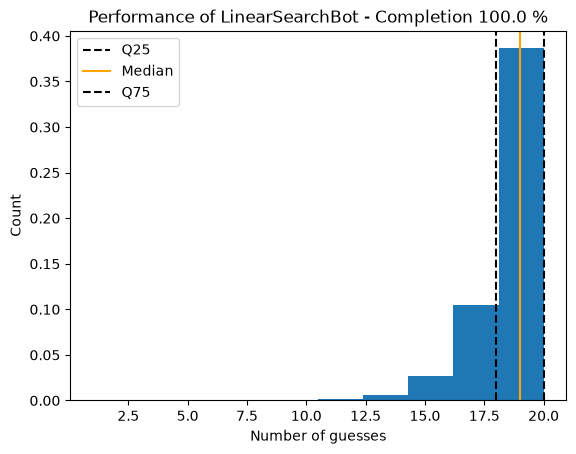

In [41]:
fig, ax, (count, bins) = statistics_single_run.plot(density=True)
# ax.plot(x, (1 - f)**(x - 1)*f, 'o', label='Expected count')
ax.legend()

### Average performance of binary search bot

In [ ]:
"""
Running 10_000 simulations for each size in [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
"""
import time
import numpy as np

N_RUNS = 10_000
bot = BinarySearchBot()

sizes = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]

dataset_binary_search_bot = {}
for n_max in sizes:
    print(f"Measure data for {n_max=} in: ", end="")
    game = Game(bot, max_target=n_max, max_questions=50_000)
    t_start = time.perf_counter()
    dataset_binary_search_bot[n_max] = RunStatistics(BinarySearchBot, [game.run() for _ in range(N_RUNS)])
    t_end = time.perf_counter()
    print(f"{t_end - t_start:0.1f} seconds")
dataset_binary_search_bot

Measure data for n_max=100 in: 2.6 seconds
Measure data for n_max=500 in: 0.6 seconds
Measure data for n_max=1000 in: 0.2 seconds
Measure data for n_max=5000 in: 0.1 seconds
Measure data for n_max=10000 in: 0.1 seconds
Measure data for n_max=50000 in: 0.1 seconds
Measure data for n_max=100000 in: 0.1 seconds
Measure data for n_max=500000 in: 0.1 seconds
Measure data for n_max=1000000 in: 0.1 seconds


{100: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9895, mean=5.804345629105609, std=1.3218328486768522, quarentiles=QuartilesInfo(minimum=1, quarentile_25=5, median=6, quarentile_75=7, maximum=7), completion_percentage=98.95),
 500: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9978, mean=7.987372218881539, std=1.3760799980845964, quarentiles=QuartilesInfo(minimum=1, quarentile_25=7, median=8, quarentile_75=9, maximum=9), completion_percentage=99.78),
 1000: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9993, mean=9.001000700490343, std=1.374813110269918, quarentiles=QuartilesInfo(minimum=1, quarentile_25=9, median=9, quarentile_75=10, maximum=10), completion_percentage=99.93),
 5000: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9999, mean=11.36023602360236, std=1.5036938529298767, quarentiles=QuartilesInfo(minimum=1, quarentile_25=11, median=12, quarentile_75=12, maximum=13), completion_percentage=99.99),
 

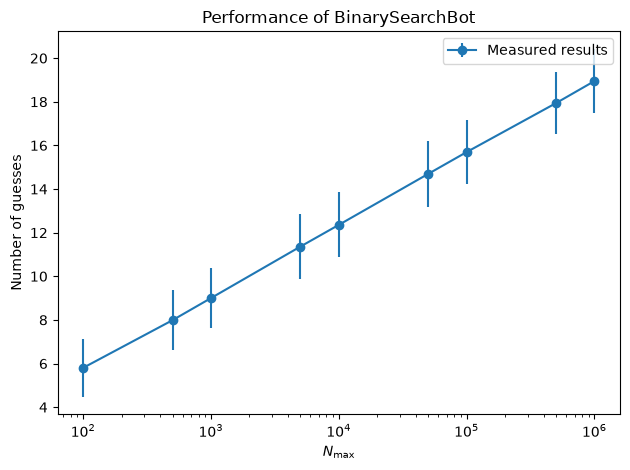

In [ ]:
import numpy as np

size_array = np.array(list(dataset_binary_search_bot), dtype=int)
data_array = np.array([data.quarentiles for data in dataset_binary_search_bot.values()]).T

fig, ax = plt.subplots()
ax.errorbar(size_array,
            np.array([data.mean for data in dataset_binary_search_bot.values()]),
            np.array([data.std for data in dataset_binary_search_bot.values()]),
            marker='o',
            label='Measured results'
            )

ax.set_xlabel('$N_\\text{max}$')
ax.set_ylabel('Number of guesses')
ax.set_title('Performance of BinarySearchBot')
ax.set_xscale('log')
ax.legend()
fig.tight_layout()